# Spatiotemporal Vulnerability Assessment

This notebook computes the spatiotemporal vulnerability layer (L3) for four evaluation times, one per
activity regime, with VERUS. The outputs feed notebook 06 (layer integration) and notebook 08 (CRI).

Inputs:

- Points of temporal influence (POTIs): `../data/poti/<city>_dataset_buffered.csv`.
- Time-window table T1g: `../data/time_windows/time_windows_T1g.csv`. Every category has continuous
  occupancy between its peaks, hospitals and stations keep a low level at night, and schools are active at
  the gates (08:00–10:00 and 16:00–18:00).
- Scenarios: `../data/time_windows/scenarios_T1g.csv` (s1 weekday morning rush, s2 weekday late morning,
  s3 weekday night, s4 Saturday daytime).

Method notes:

- Requires verus after 1.1.1 (commit `de4850c` of the verus repository): vulnerability is normalized with a
  zero baseline (`value / max_vulnerability`), time windows are applied to the loaded POTIs on every
  `run()`, so scenarios evaluated in sequence do not inherit each other's `vi` values, and only the POTIs
  active at the evaluation time (`vi > 0`) are clustered. Up to 1.1.1, OPTICS clustered every POTI, so the
  clusters were the same in all scenarios and inactive POTIs diluted the vulnerability of their cluster.
- `max_vulnerability` is the largest raw vulnerability over the four scenarios. A first pass computes it,
  and a second pass normalizes every scenario with it, so the four layers share one scale.

The article version of this notebook used `default_time_windows.csv` and four other evaluation times; it is
kept in the git history.

In [1]:
import json
import os

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import verus
from verus import VERUS
from verus.data import TimeWindowGenerator
from verus.grid import HexagonGridGenerator

print("verus", verus.__version__)

verus

1.1.1.post4

## 1. Parameters and data

In [2]:
city = "Lisbon"

poti_path = f"../data/poti/{city.lower()}_dataset_buffered.csv"
time_windows_path = "../data/time_windows/time_windows_T1g.csv"
scenarios_path = "../data/time_windows/scenarios_T1g.csv"
boundary_path = f"../data/cities/{city.lower()}.geojson"
output_dir = f"../data/vulnerability_layer/{city.lower()}"

clustering = {
    "optics": {"min_samples": 5, "xi": 0.05, "min_cluster_size": 5},
    "kmeans": {"init": "predefined", "random_state": 42},
}

In [3]:
poti_df = pd.read_csv(poti_path)
time_windows_df = pd.read_csv(time_windows_path)
scenarios = pd.read_csv(scenarios_path)
scenarios["epoch"] = scenarios["evaluation_time"].map(TimeWindowGenerator.to_unix_epoch)


def active_windows(epoch):
    tw = time_windows_df
    act = tw[(tw["ts"] <= epoch) & (tw["te"] >= epoch)]
    return ", ".join(f"{c}={vi:g}" for c, vi in sorted(set(zip(act["category"], act["vi"]))))


scenarios["active_categories"] = scenarios["epoch"].map(active_windows)
print(f"{len(poti_df)} POTIs, {len(time_windows_df)} time windows")
scenarios[["scenario", "regime", "evaluation_time", "active_categories"]]

776 POTIs, 128 time windows

,scenario,regime,evaluation_time,active_categories
0,s1,Weekday morning rush,2023-11-06 08:30:00,"bus_station=0.5, hospital=0.8, industrial=0.6,..."
1,s2,Weekday late morning,2023-11-06 11:00:00,"attraction=0.5, bus_station=0.2, hospital=0.4,..."
2,s3,Weekday night,2023-11-06 21:00:00,"bus_station=0.2, hospital=0.2, station=0.3"
3,s4,Saturday daytime,2023-11-11 11:00:00,"attraction=0.7, hospital=0.2, mall=0.2, statio..."


### 1.1. Hexagonal grid (100 m edge)

In [4]:
hex_grid = HexagonGridGenerator(region=boundary_path, edge_length=100).run()
print(f"{len(hex_grid)} hexagons")

2026-09-22 16:27:05 [

INFO

] Initialized grid generator for region from file: lisbon.geojson


2026-09-22 16:27:05 [

INFO

...

] Clipping grid to region boundaries


2026-09-22 16:27:06 [

INFO

] Clipped from 11131 to 6569 hexagons


6569 hexagons

## 2. Maximum vulnerability over the scenarios

First pass with `max_vulnerability = 1.0`, so that `VL_normalized` equals the raw vulnerability. The
maximum of the raw values over the four scenarios becomes the normalization constant of the second pass.

In [5]:
def make_assessor(max_vulnerability):
    config = {"max_vulnerability": {city: max_vulnerability}, "clustering": clustering}
    assessor = VERUS(place_name=city, config=config, verbose=False)
    assessor.load(potis_df=poti_df, time_windows_df=time_windows_df, zones_gdf=hex_grid)
    return assessor


first_pass = make_assessor(1.0)
raw_max = {}
for _, sc in scenarios.iterrows():
    zones = first_pass.run(evaluation_time=int(sc["epoch"]))["vulnerability_zones"]
    raw_max[sc["scenario"]] = zones["value"].max()

max_vulnerability = max(raw_max.values())
print("Raw maximum per scenario:", {k: f"{v:.6e}" for k, v in raw_max.items()})
print(f"max_vulnerability = {max_vulnerability:.10e}")

2026-09-22 16:27:06 [

INFO

] VulnerabilityAssessor initialized for Lisbon using gaussian method


2026-09-22 16:27:06 [

WARNING

...

INFO

] count    6569.000000
mean        0.000091
std         0.000050
min         0.000004
25%         0.000052
50%         0.000083
75%         0.000122
max         0.000234
Name: VL_normalized_smoothed, dtype: float64


Raw maximum per scenario:

{'s1': '2.421272e-04', 's2': '1.842776e-04', 's3': '7.698318e-05', 's4': '2.336724e-04'}

max_vulnerability = 2.4212717181e-04

## 3. Vulnerability per scenario

Each layer is saved as `<City>_vulnerability_zones_<scenario>.geojson`, the path notebook 06 reads.

In [6]:
os.makedirs(output_dir, exist_ok=True)
assessor = make_assessor(max_vulnerability)
layers = {}
for _, sc in scenarios.iterrows():
    zones = assessor.run(evaluation_time=int(sc["epoch"]))["vulnerability_zones"]
    assert zones["VL_normalized"].max() <= 1 + 1e-12
    path = os.path.join(output_dir, f"{city}_vulnerability_zones_{sc['scenario']}.geojson")
    zones.to_file(path, driver="GeoJSON")
    layers[sc["scenario"]] = zones
    print(f"{sc['scenario']} ({sc['regime']}): saved {path}")

metadata = {
    "city": city,
    "verus_version": verus.__version__,
    "time_windows": os.path.basename(time_windows_path),
    "scenarios": scenarios[["scenario", "regime", "evaluation_time"]].to_dict(orient="records"),
    "max_vulnerability": max_vulnerability,
    "raw_max_per_scenario": raw_max,
    "clustering": clustering,
    "edge_length_m": 100,
}
with open(os.path.join(output_dir, "vulnerability_metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2)

pd.DataFrame({s: z["VL_normalized_smoothed"].describe() for s, z in layers.items()}).round(3)

2026-09-22 16:28:14 [

INFO

] VulnerabilityAssessor initialized for Lisbon using gaussian method


2026-09-22 16:28:14 [

WARNING

...

2026-09-22 16:29:23 [

INFO

] count    6569.000000
mean        0.375357
std         0.205211
min         0.017403
25%         0.216357
50%         0.343198
75%         0.503323
max         0.965081
Name: VL_normalized_smoothed, dtype: float64


s4 (Saturday daytime): saved ../data/vulnerability_layer/lisbon/Lisbon_vulnerability_zones_s4.geojson

,s1,s2,s3,s4
count,6569.000,6569.000,6569.000,6569.000
mean,0.551,0.360,0.119,0.375
std,0.162,0.150,0.071,0.205
min,0.061,0.015,0.002,0.017
25%,0.442,0.232,0.064,0.216
50%,0.554,0.366,0.107,0.343
75%,0.660,0.483,0.172,0.503
max,1.000,0.761,0.318,0.965


## 4. Maps of the vulnerability layers

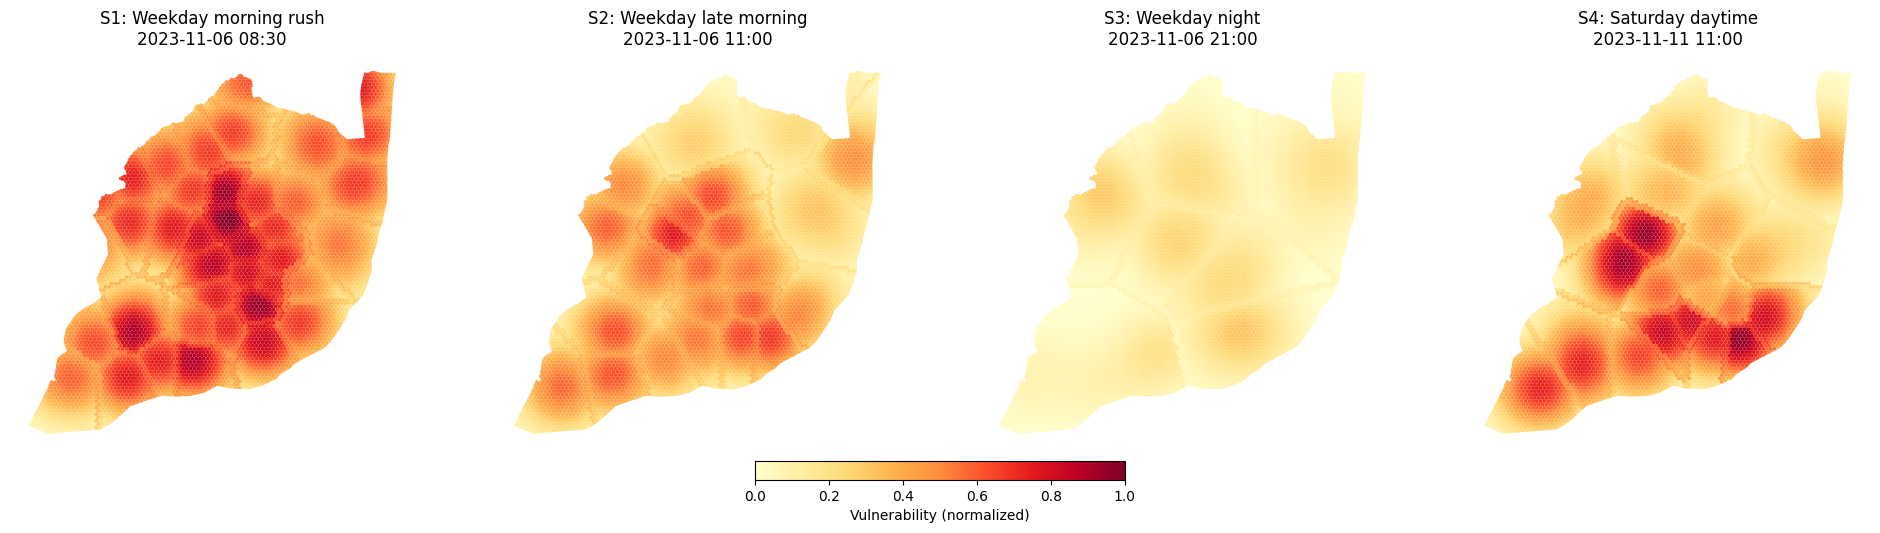

In [7]:
fig, axes = plt.subplots(1, len(layers), figsize=(6 * len(layers), 6))
for ax, (_, sc) in zip(axes, scenarios.iterrows()):
    layers[sc["scenario"]].plot(column="VL_normalized_smoothed", cmap="YlOrRd", vmin=0, vmax=1, ax=ax)
    ax.set_title(f"{sc['scenario'].upper()}: {sc['regime']}\n{sc['evaluation_time'][:16]}", fontsize=12)
    ax.set_axis_off()
sm = plt.cm.ScalarMappable(cmap="YlOrRd", norm=plt.Normalize(0, 1))
fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.04, pad=0.02, label="Vulnerability (normalized)")
plt.show()